# Smartphone Battery Drain Prediction Using Machine Learning

## Techniques Used
1. Exploratory Data Analysis (EDA)
2. Simple Linear Regression
3. Multiple Linear Regression
4. Logistic Regression
5. Clustering Techniques
   - K-Means
   - Hierarchical Clustering
   - DBSCAN

## Objective
The objective of this project is to analyze smartphone usage behavior and predict battery drain using various Machine Learning techniques.

# Problem Statement

Smartphone battery performance is heavily influenced by user behavior such as gaming, screen brightness, app usage, GPS usage, and streaming activities.

This project aims to:
- Analyze user behavior patterns
- Predict battery drain percentage
- Classify fast battery drain conditions
- Identify behavioral user groups using clustering techniques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Phase 1: Data Understanding & EDA

In [2]:
df = pd.read_csv("smartphone_battery_drain_dataset.csv")

In [3]:
df.head()

,Screen_Brightness,Gaming_Hours,App_Usage_Hours,GPS_Usage,Bluetooth_On,WiFi_Usage_Hours,Video_Streaming_Hours,Charging_Cycles,Battery_Drain_Percentage,Fast_Drain
0,66,7.61,10.52,3.59,0,2.72,0.41,3.53,75.11,1
1,36,0.45,10.39,5.63,0,11.91,4.32,2.64,46.04,0
2,63,4.20,6.20,0.28,1,3.56,0.63,2.66,56.66,0
3,17,6.88,9.84,2.70,0,11.36,3.94,1.85,67.34,1
4,67,1.85,4.13,4.10,1,10.17,1.21,1.87,46.95,0


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (3000, 10)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Screen_Brightness         3000 non-null   int64  
 1   Gaming_Hours              3000 non-null   float64
 2   App_Usage_Hours           3000 non-null   float64
 3   GPS_Usage                 3000 non-null   float64
 4   Bluetooth_On              3000 non-null   int64  
 5   WiFi_Usage_Hours          3000 non-null   float64
 6   Video_Streaming_Hours     3000 non-null   float64
 7   Charging_Cycles           3000 non-null   float64
 8   Battery_Drain_Percentage  3000 non-null   float64
 9   Fast_Drain                3000 non-null   int64  
dtypes: float64(7), int64(3)
memory usage: 234.5 KB


In [6]:
df.describe()

,Screen_Brightness,Gaming_Hours,App_Usage_Hours,GPS_Usage,Bluetooth_On,WiFi_Usage_Hours,Video_Streaming_Hours,Charging_Cycles,Battery_Drain_Percentage,Fast_Drain
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,57.945667,3.986687,7.504240,2.967140,0.547333,6.443873,3.480483,2.274727,59.897907,0.376333
std,24.835304,2.319709,3.755122,1.740091,0.497837,3.188869,2.011431,1.002547,14.925437,0.484546
min,15.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.500000,12.000000,0.000000
25%,36.000000,1.940000,4.260000,1.460000,0.000000,3.680000,1.720000,1.430000,49.410000,0.000000
50%,58.000000,3.980000,7.630000,2.975000,1.000000,6.390000,3.480000,2.290000,60.335000,0.000000
75%,80.000000,5.990000,10.692500,4.470000,1.000000,9.202500,5.200000,3.120000,69.812500,1.000000
max,100.000000,7.990000,14.000000,6.000000,1.000000,11.980000,7.000000,4.000000,98.000000,1.000000


In [7]:
missing_values = df.isnull().sum()

print(missing_values)

Screen_Brightness           0
Gaming_Hours                0
App_Usage_Hours             0
GPS_Usage                   0
Bluetooth_On                0
WiFi_Usage_Hours            0
Video_Streaming_Hours       0
Charging_Cycles             0
Battery_Drain_Percentage    0
Fast_Drain                  0
dtype: int64


- No missing values were found in the dataset.
- Therefore, no imputation or removal was required.

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


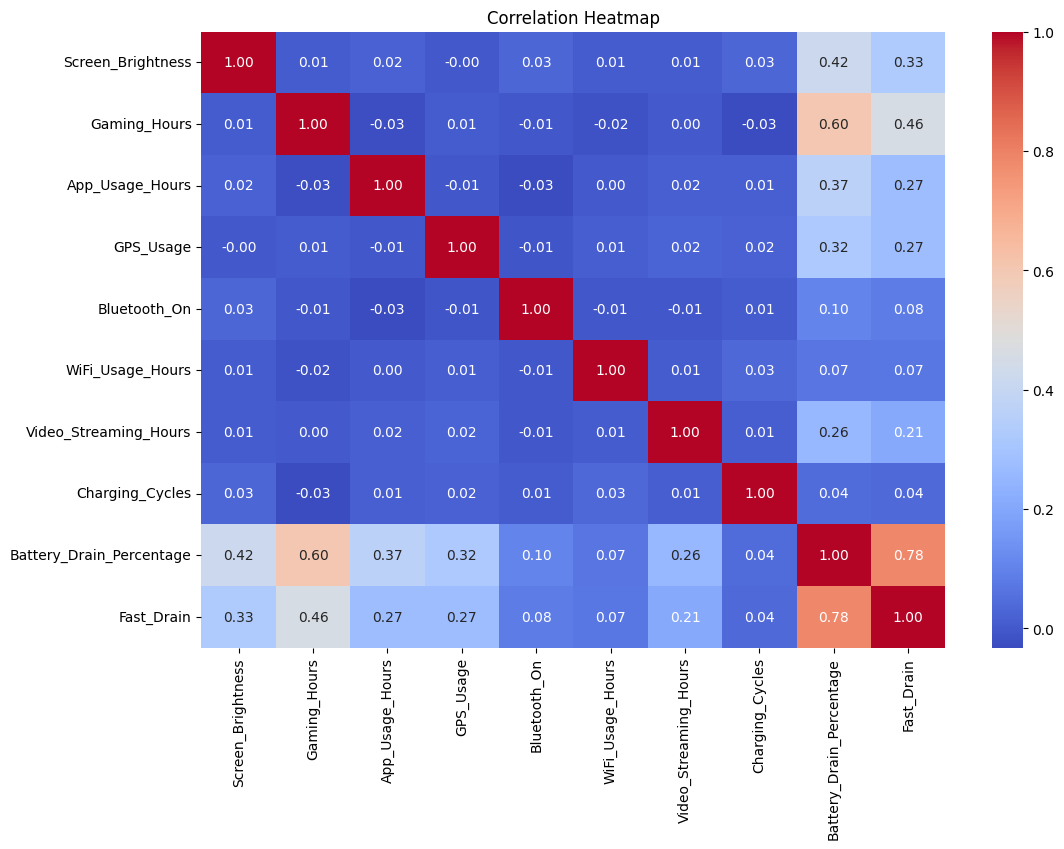

In [9]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

- Gaming hours positively affect battery drain
- Screen brightness strongly impacts battery usage
- GPS usage contributes to battery drain
- Fast_Drain highly correlates with Battery_Drain_Percentage

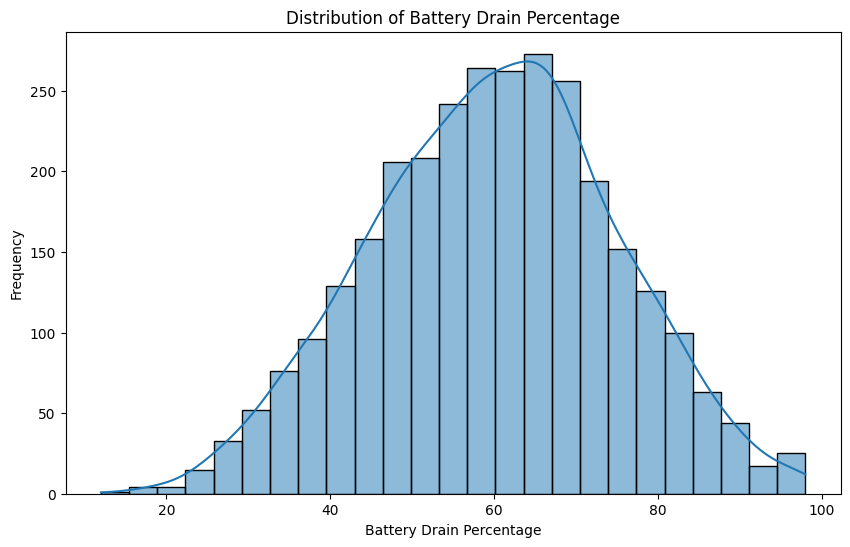

In [10]:
# Battery Drain Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    df['Battery_Drain_Percentage'],
    bins=25,
    kde=True
)

plt.title("Distribution of Battery Drain Percentage")

plt.xlabel("Battery Drain Percentage")
plt.ylabel("Frequency")

plt.show()

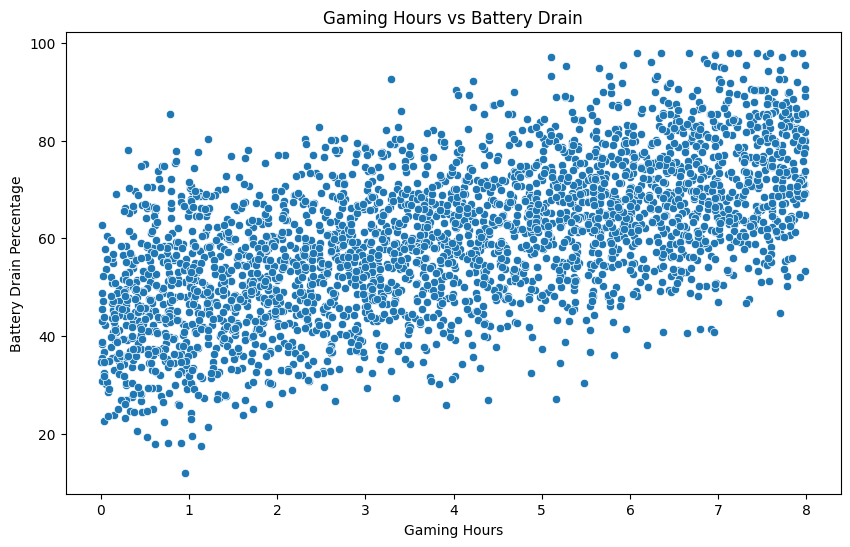

In [11]:
# Gaming Hours vs Battery Drain

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['Gaming_Hours'],
    y=df['Battery_Drain_Percentage']
)

plt.title("Gaming Hours vs Battery Drain")

plt.xlabel("Gaming Hours")
plt.ylabel("Battery Drain Percentage")

plt.show()

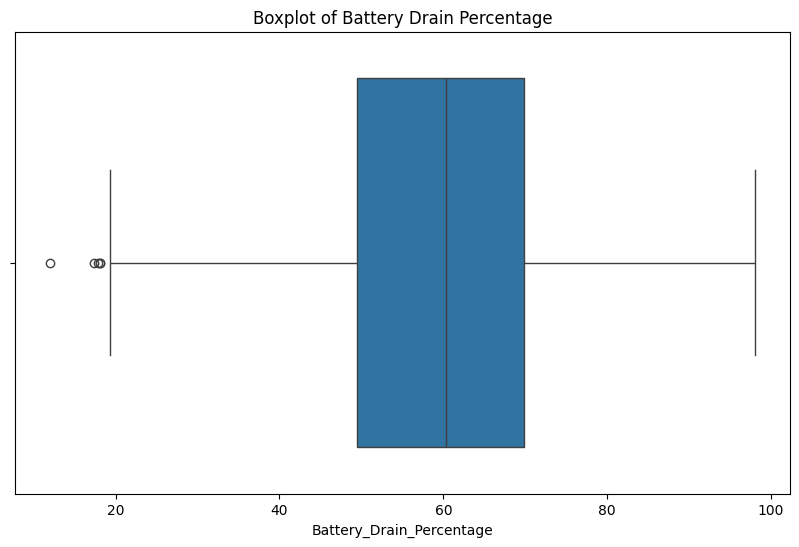

In [12]:
# Outlier Detection
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df['Battery_Drain_Percentage']
)

plt.title("Boxplot of Battery Drain Percentage")

plt.show()

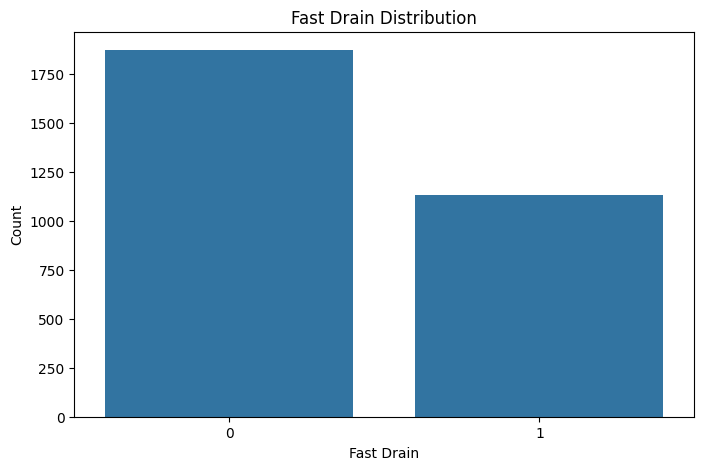

In [13]:
# Fast Drain Class Distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    x=df['Fast_Drain']
)

plt.title("Fast Drain Distribution")

plt.xlabel("Fast Drain")
plt.ylabel("Count")

plt.show()

- Dataset has both fast-drain and normal-drain users
- Classification target is reasonably balanced

# Phase 1 Conclusion

- The dataset contains 3000 records and 10 features.
- No missing or duplicate values were found.
- Gaming hours, GPS usage, and screen brightness show strong relationships with battery drain.
- Battery drain distribution appears realistic with moderate variance.
- The Fast_Drain target is suitable for classification tasks.
- The selected features are appropriate for regression and clustering techniques.

# Phase 2: Simple Linear Regression

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [15]:
X = df[['Gaming_Hours']]

y = df['Battery_Drain_Percentage']

In [16]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape: (2400, 1)
Testing Data Shape : (600, 1)


In [17]:
slr_model = LinearRegression()

slr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
print("Intercept:", slr_model.intercept_)

print("Coefficient:", slr_model.coef_[0])

Intercept: 44.364468874137984
Coefficient: 3.9137840699128645


In [19]:
y_pred = slr_model.predict(X_test)

In [20]:
# Model Evaluation


mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE  :", round(mae, 2))

print("RMSE :", round(rmse, 2))

print("R² Score :", round(r2, 2))

MAE  : 9.72
RMSE : 12.32
R² Score : 0.34


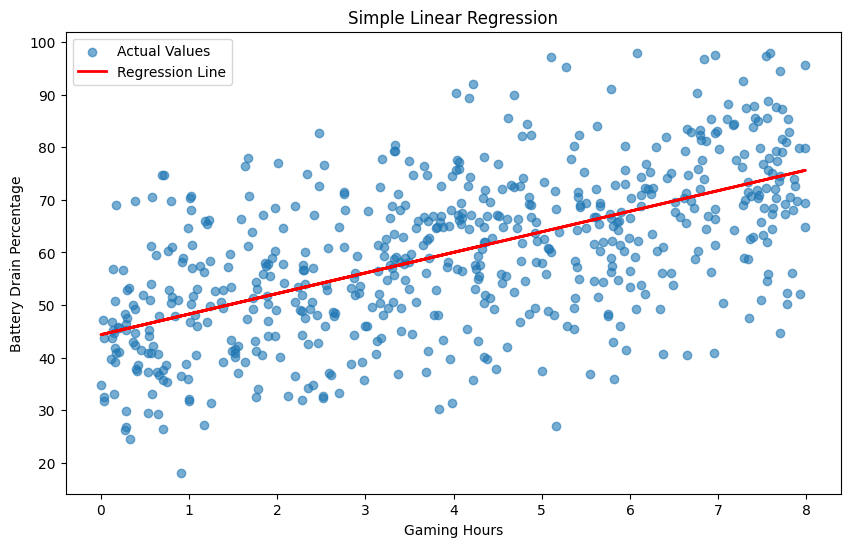

In [21]:
# Regression Line Visualization


plt.figure(figsize=(10, 6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.6,
    label='Actual Values'
)

plt.plot(
    X_test,
    y_pred,
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.title("Simple Linear Regression")

plt.xlabel("Gaming Hours")

plt.ylabel("Battery Drain Percentage")

plt.legend()

plt.show()

In [22]:
# Residual Calculation

residuals = y_test - y_pred

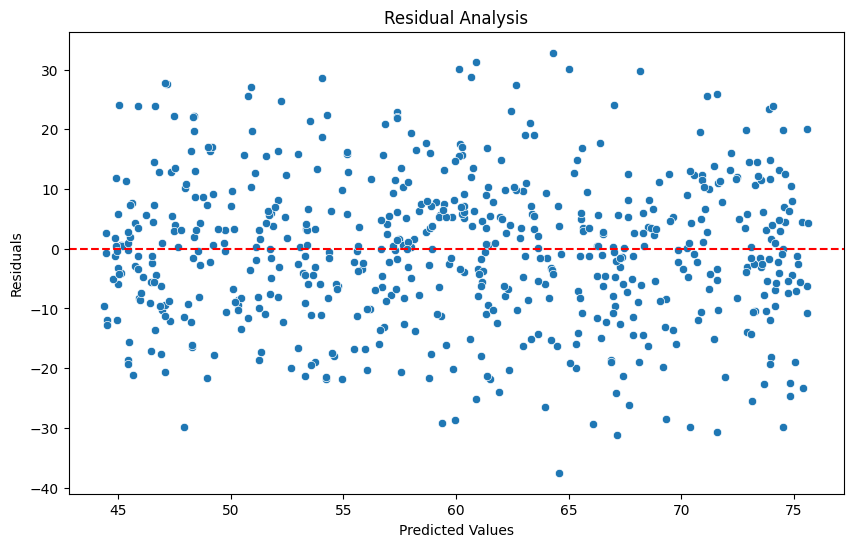

In [23]:
# Residual Plot


plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residual Analysis")

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.show()

- Residuals are distributed around zero.
- No major pattern is visible.
- This indicates the linear model is reasonably appropriate.

In [24]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison_df.head(10)

,Actual,Predicted
0,60.74,61.272016
1,60.26,47.338945
2,39.07,55.949270
3,65.58,70.312857
4,61.65,66.242522
5,48.03,59.315124
6,60.99,69.334411
7,71.66,64.520457
8,37.75,45.929983
9,69.94,72.935093


# Phase 2 Conclusion

- Simple Linear Regression was used to predict battery drain percentage using gaming hours.
- The model showed a positive linear relationship between gaming hours and battery drain.
- Evaluation metrics indicate that gaming activity significantly influences battery consumption.
- Residual analysis suggests that the model performs reasonably well for basic prediction.

# Phase 3: Multiple Linear Regression

In [25]:
from sklearn.feature_selection import RFE

from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.api as sm

In [26]:
X = df[
    [
        'Screen_Brightness',
        'Gaming_Hours',
        'App_Usage_Hours',
        'GPS_Usage',
        'Video_Streaming_Hours'
    ]
]

y = df['Battery_Drain_Percentage']

In [27]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
# Train Multiple Linear Regression Model

mlr_model = LinearRegression()

mlr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
y_pred_mlr = mlr_model.predict(X_test)

In [30]:
# Model Evaluation

mae_mlr = mean_absolute_error(y_test, y_pred_mlr)

mse_mlr = mean_squared_error(y_test, y_pred_mlr)

rmse_mlr = np.sqrt(mse_mlr)

r2_mlr = r2_score(y_test, y_pred_mlr)

print("MAE  :", round(mae_mlr, 2))

print("RMSE :", round(rmse_mlr, 2))

print("R² Score :", round(r2_mlr, 2))

MAE  : 4.72
RMSE : 6.04
R² Score : 0.84


In [31]:
# Feature Coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_
})

coefficients

,Feature,Coefficient
0,Screen_Brightness,0.243993
1,Gaming_Hours,3.909856
2,App_Usage_Hours,1.459105
3,GPS_Usage,2.696567
4,Video_Streaming_Hours,1.744368


Positive coefficient means:

- increasing that feature increases battery drain.

Larger coefficient magnitude:

- stronger influence on battery consumption.

In [32]:
# VIF Calculation

X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,Feature,VIF
0,const,18.934653
1,Screen_Brightness,1.000466
2,Gaming_Hours,1.000763
3,App_Usage_Hours,1.001311
4,GPS_Usage,1.000728
5,Video_Streaming_Hours,1.000950


In [33]:
# Recursive Feature Elimination (RFE)

rfe = RFE(
    estimator=LinearRegression(),
    n_features_to_select=3
)

rfe.fit(X, y)

,estimator,LinearRegression()
,n_features_to_select,3
,step,1
,verbose,0
,importance_getter,'auto'
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
feature_selection = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
})

feature_selection

,Feature,Selected,Ranking
0,Screen_Brightness,False,3
1,Gaming_Hours,True,1
2,App_Usage_Hours,False,2
3,GPS_Usage,True,1
4,Video_Streaming_Hours,True,1


In [35]:
# SLR vs MLR Comparison

comparison = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression'],
    
    'MAE': [
        round(mae, 2),
        round(mae_mlr, 2)
    ],
    
    'RMSE': [
        round(rmse, 2),
        round(rmse_mlr, 2)
    ],
    
    'R² Score': [
        round(r2, 2),
        round(r2_mlr, 2)
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Simple Linear Regression,9.72,12.32,0.34
1,Multiple Linear Regression,4.72,6.04,0.84


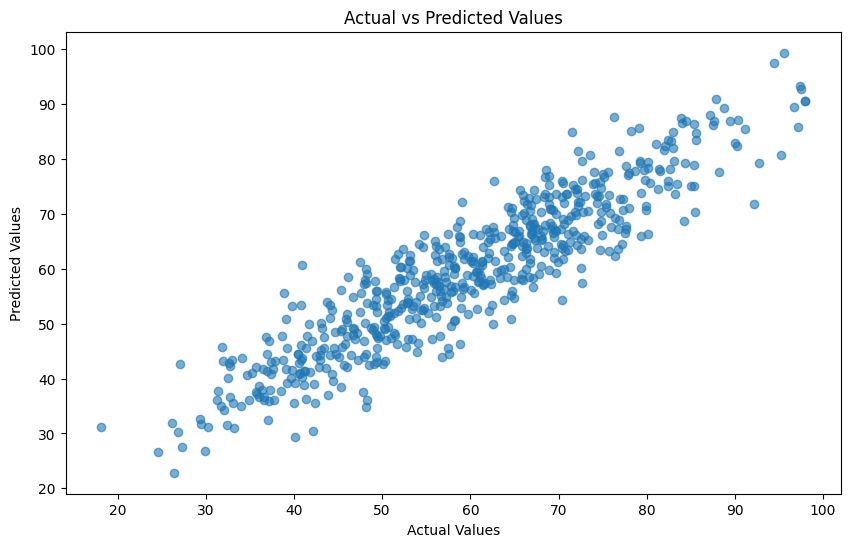

In [36]:
# Actual vs Predicted Plot

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_mlr,
    alpha=0.6
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()

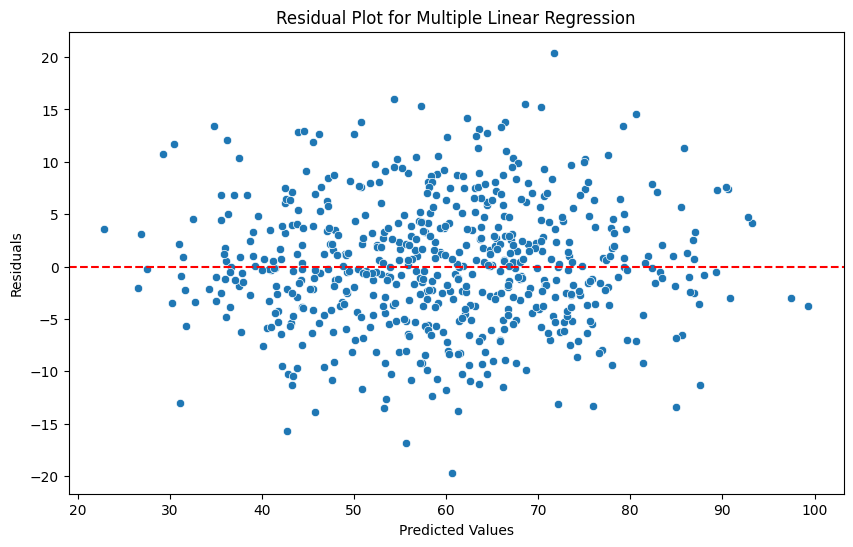

In [37]:
# Residual Analysis

residuals_mlr = y_test - y_pred_mlr

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred_mlr,
    y=residuals_mlr
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot for Multiple Linear Regression")

plt.show()

# Phase 3 Conclusion

- Multiple Linear Regression was used to predict battery drain percentage using multiple smartphone usage features.
- The model achieved better performance than Simple Linear Regression.
- VIF analysis showed acceptable multicollinearity among features.
- RFE identified the most influential features affecting battery drain.
- Residual analysis indicated that the model fits the data reasonably well.

# Phase 4: Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [39]:
X = df[
    [
        'Screen_Brightness',
        'Gaming_Hours',
        'App_Usage_Hours',
        'GPS_Usage',
        'Video_Streaming_Hours'
    ]
]

y = df['Fast_Drain']

In [40]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
# Train Logistic Regression Model

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
# Predictions

y_pred = log_model.predict(X_test)

In [43]:
# Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 2))

print("Precision:", round(precision, 2))

print("Recall   :", round(recall, 2))

print("F1 Score :", round(f1, 2))

Accuracy : 0.88
Precision: 0.88
Recall   : 0.8
F1 Score : 0.84


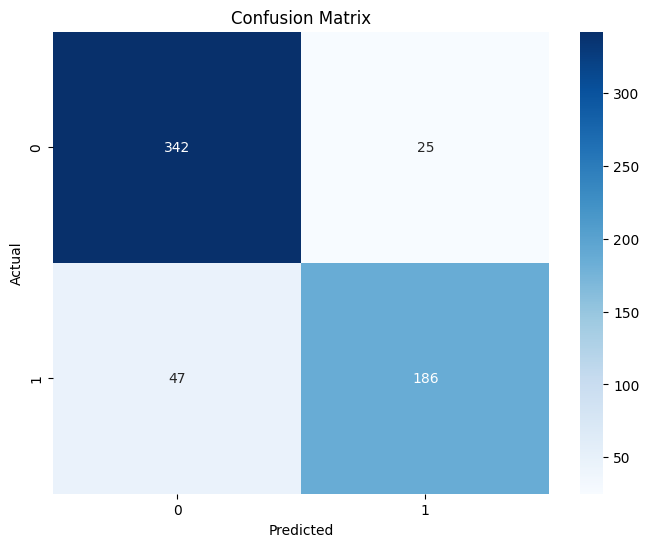

In [44]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [45]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       367
           1       0.88      0.80      0.84       233

    accuracy                           0.88       600
   macro avg       0.88      0.87      0.87       600
weighted avg       0.88      0.88      0.88       600



In [46]:
# Prediction Probabilities

y_prob = log_model.predict_proba(X_test)[:, 1]

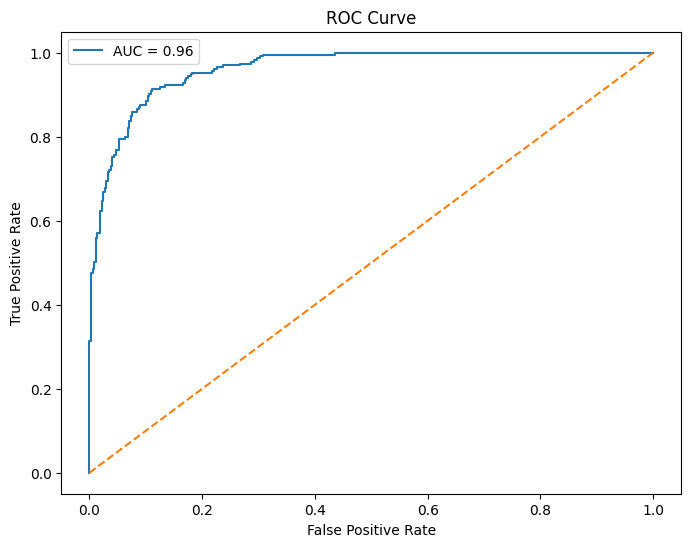

In [47]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [48]:
# Find Optimal Threshold

optimal_idx = np.argmax(tpr - fpr)

optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", round(optimal_threshold, 2))

Optimal Threshold: 0.35


In [49]:
# Predictions Using Optimal Threshold

y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

In [50]:
# Evaluation with Optimal Threshold

print("Accuracy :", round(accuracy_score(y_test, y_pred_optimal), 2))

print("Precision:", round(precision_score(y_test, y_pred_optimal), 2))

print("Recall   :", round(recall_score(y_test, y_pred_optimal), 2))

print("F1 Score :", round(f1_score(y_test, y_pred_optimal), 2))

Accuracy : 0.9
Precision: 0.84
Recall   : 0.91
F1 Score : 0.87


In [51]:
# Logistic Regression Coefficients

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

importance

,Feature,Coefficient
0,Screen_Brightness,0.067952
1,Gaming_Hours,0.979335
2,App_Usage_Hours,0.374926
3,GPS_Usage,0.789863
4,Video_Streaming_Hours,0.471837


Positive coefficient:

- increases probability of fast battery drain.

Higher magnitude:

- stronger influence on fast drain classification.

# Phase 4 Conclusion

- Logistic Regression was used to classify fast and normal battery drain conditions.
- The model achieved good classification performance based on accuracy, precision, recall, and F1 score.
- ROC-AUC analysis showed strong separability between classes.
- Optimal threshold selection improved classification decision-making.
- Gaming hours, screen brightness, and app usage significantly influenced fast battery drain prediction.

# Phase 5: Clustering

In [52]:
# Import Required Libraries

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)

from sklearn.cluster import DBSCAN

In [53]:
# Select Features for Clustering

clustering_features = df[
    [
        'Gaming_Hours',
        'App_Usage_Hours',
        'GPS_Usage',
        'Video_Streaming_Hours',
        'Screen_Brightness'
    ]
]

clustering_features.head()

,Gaming_Hours,App_Usage_Hours,GPS_Usage,Video_Streaming_Hours,Screen_Brightness
0,7.61,10.52,3.59,0.41,66
1,0.45,10.39,5.63,4.32,36
2,4.20,6.20,0.28,0.63,63
3,6.88,9.84,2.70,3.94,17
4,1.85,4.13,4.10,1.21,67


In [54]:
# Feature Scaling

scaler = StandardScaler()

scaled_features = scaler.fit_transform(clustering_features)

### PART A: K-MEANS CLUSTERING

In [55]:
# Elbow Method

wcss = []

K_range = range(1, 11)

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(scaled_features)
    
    wcss.append(kmeans.inertia_)

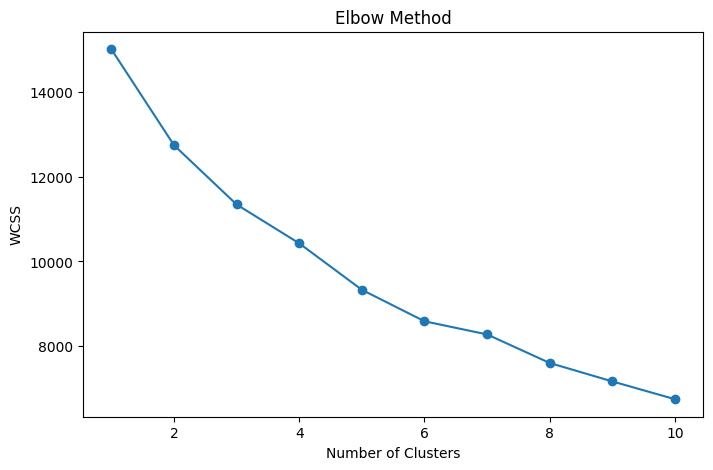

In [56]:
# Plot Elbow Curve

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [57]:
# Silhouette Scores

silhouette_scores = []

for k in range(2, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    cluster_labels = kmeans.fit_predict(scaled_features)
    
    score = silhouette_score(
        scaled_features,
        cluster_labels
    )
    
    silhouette_scores.append(score)
    
    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.149
K = 3, Silhouette Score = 0.138
K = 4, Silhouette Score = 0.136
K = 5, Silhouette Score = 0.151
K = 6, Silhouette Score = 0.157
K = 7, Silhouette Score = 0.145
K = 8, Silhouette Score = 0.160
K = 9, Silhouette Score = 0.163
K = 10, Silhouette Score = 0.169


In [58]:
# Train Final K-Means Model

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_features)

df['KMeans_Cluster'] = clusters

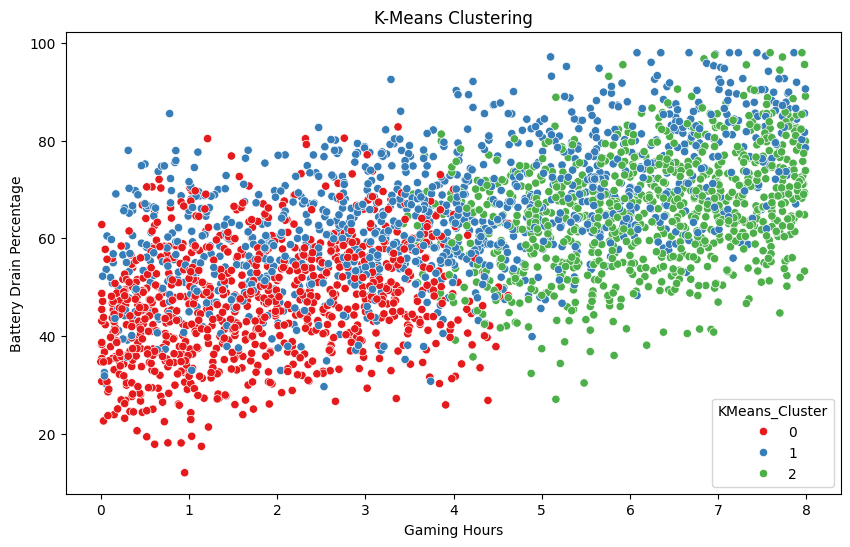

In [59]:
# Visualize K-Means Clusters

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['Gaming_Hours'],
    y=df['Battery_Drain_Percentage'],
    hue=df['KMeans_Cluster'],
    palette='Set1'
)

plt.title("K-Means Clustering")

plt.xlabel("Gaming Hours")

plt.ylabel("Battery Drain Percentage")

plt.show()

In [60]:
# Cluster Statistics

cluster_summary = df.groupby('KMeans_Cluster')[
    [
        'Gaming_Hours',
        'App_Usage_Hours',
        'GPS_Usage',
        'Video_Streaming_Hours',
        'Battery_Drain_Percentage'
    ]
].mean()

cluster_summary

,Gaming_Hours,App_Usage_Hours,GPS_Usage,Video_Streaming_Hours,Battery_Drain_Percentage
KMeans_Cluster,,,,,
0,1.824684,5.172331,2.864499,3.537146,46.864913
1,3.987383,11.296304,2.799881,3.521988,65.807179
2,6.178840,4.937867,3.288785,3.369028,65.432796


### PART B: HIERARCHICAL CLUSTERING

In [61]:
# Hierarchical Clustering Linkage

linked = linkage(
    scaled_features,
    method='ward'
)

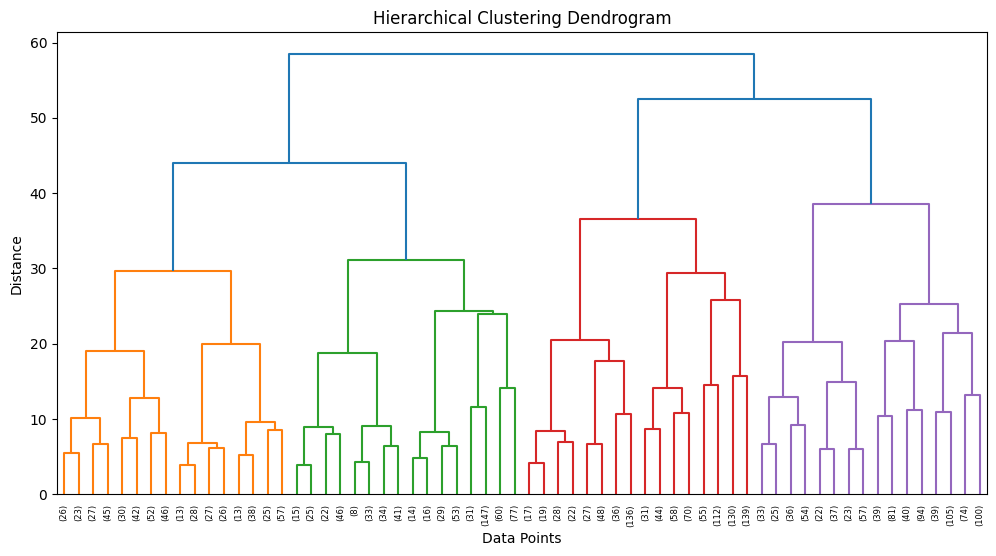

In [62]:
# Dendrogram

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Distance")

plt.show()

### PART C: DBSCAN

In [63]:
# DBSCAN Clustering

dbscan = DBSCAN(
    eps=1.2,
    min_samples=10
)

dbscan_clusters = dbscan.fit_predict(scaled_features)

df['DBSCAN_Cluster'] = dbscan_clusters

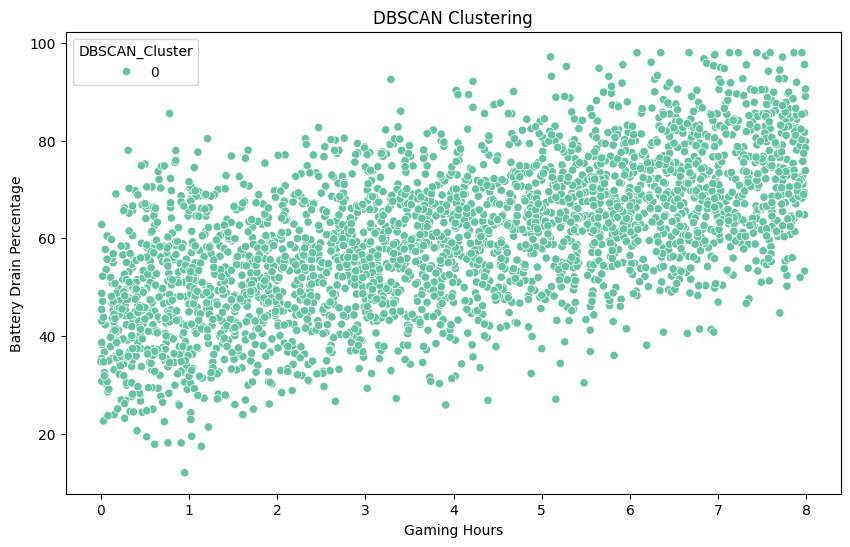

In [64]:
# Visualize DBSCAN Clusters

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['Gaming_Hours'],
    y=df['Battery_Drain_Percentage'],
    hue=df['DBSCAN_Cluster'],
    palette='Set2'
)

plt.title("DBSCAN Clustering")

plt.xlabel("Gaming Hours")

plt.ylabel("Battery Drain Percentage")

plt.show()

In [65]:
# Compare Clustering Methods

print("K-Means Unique Clusters:")

print(df['KMeans_Cluster'].unique())

print("\nDBSCAN Unique Clusters:")

print(df['DBSCAN_Cluster'].unique())

K-Means Unique Clusters:
[2 0 1]

DBSCAN Unique Clusters:
[0]


# Phase 5 Conclusion

- K-Means clustering grouped smartphone users into distinct behavioral categories.
- Elbow method and silhouette score helped determine the optimal number of clusters.
- Hierarchical clustering confirmed natural group separation through dendrogram analysis.
- DBSCAN identified dense behavioral groups and detected noise points.
- Heavy gaming, high screen brightness, and streaming activity were major characteristics of high battery-drain user clusters.

In [69]:
final_comparison = pd.DataFrame({
    'Technique': [
        'Simple Linear Regression',
        'Multiple Linear Regression',
        'Logistic Regression'
    ],
    
    'Main Metric': [
        round(r2, 2),
        round(r2_mlr, 2),
        round(accuracy, 2)
    ],
    
    'Metric Type': [
        'R² Score',
        'R² Score',
        'Accuracy'
    ]
})

final_comparison

,Technique,Main Metric,Metric Type
0,Simple Linear Regression,0.34,R² Score
1,Multiple Linear Regression,0.84,R² Score
2,Logistic Regression,0.88,Accuracy


# Final Conclusion

This project analyzed smartphone battery drain behavior using multiple Machine Learning techniques.

The results showed that:
- Gaming hours, screen brightness, GPS usage, and app usage significantly affect battery drain.
- Multiple Linear Regression provided the best prediction performance for continuous battery drain estimation.
- Logistic Regression effectively classified fast battery drain conditions.
- Clustering techniques successfully identified distinct smartphone user behavior groups.

The project highlights how Machine Learning can help analyze user behavior patterns and improve battery optimization strategies.